# **Social Media Engagement Analytics Using Python**

In [1]:
  # Data Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Upload CSV

from google.colab import files

uploaded = files.upload()

# Read CSV file
df = pd.read_csv("social_media_engagement_5000.csv")

print("Dataset imported successfully!")


Saving social_media_engagement_5000.csv to social_media_engagement_5000 (1).csv
Dataset imported successfully!


In [6]:
print("Shape:", df.shape)


Shape: (5000, 19)


In [5]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [7]:
# Dataset
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of Rows: 5000
Number of Columns: 19

Column Names:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

Data Types:
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [8]:
# Convert Date Column

df['posted_at'] = pd.to_datetime(df['posted_at'], dayfirst=True, errors='coerce')

print(df['posted_at'].dtype)
print(df['posted_at'].head())

datetime64[ns]
0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[ns]


In [9]:
# Data Cleaning
# Check Missing Values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

Total Missing Values: 900


In [10]:
# Handle Missing Values
# Median for numerical columns


# Numerical columns
numeric_fill_columns = [
    'age',
    'likes',
    'comments',
    'shares'
]

# Fill numerical missing values using median
for col in numeric_fill_columns:
    df[col] = df[col].fillna(df[col].median())




In [11]:
# # Mode for categorical columns

categorical_fill_columns = [
    'gender',
    'sentiment'
]

# Fill categorical missing values using mode
for col in categorical_fill_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


print("Missing values handled successfully!")

Missing values handled successfully!


In [12]:
print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [13]:
# Duplicate Handling
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Data Formatting
# Remove unnecessary spaces
categorical_columns = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment'
]

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

df['gender'] = df['gender'].str.title()
df['country'] = df['country'].str.title()
df['post_type'] = df['post_type'].str.lower()
df['post_category'] = df['post_category'].str.lower()
df['device_type'] = df['device_type'].str.lower()
df['sentiment'] = df['sentiment'].str.lower()

print("Data Formatting is done successfully.")

Data Formatting is done successfully.


In [15]:
# Check Numerical Values

numeric_columns = [
    'age',
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'follower_count',
    'engagement_rate'
]

for col in numeric_columns:
    print(
        f"{col}: "
        f"Minimum = {df[col].min()}, "
        f"Maximum = {df[col].max()}"
    )

age: Minimum = 13.0, Maximum = 64.0
likes: Minimum = 10.0, Maximum = 19998.0
comments: Minimum = 0.0, Maximum = 2999.0
shares: Minimum = 0.0, Maximum = 1999.0
watch_time_sec: Minimum = 0, Maximum = 7998
impression_count: Minimum = 105, Maximum = 99995
follower_count: Minimum = 87, Maximum = 799533
engagement_rate: Minimum = 0.006362909, Maximum = 191.5043478


In [16]:
# Correct Negative Engagement Values

engagement_columns = [
    'likes',
    'comments',
    'shares'
]

for col in engagement_columns:
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())

print("Negative engagement values handled.")

Negative engagement values handled.


In [17]:
# Feature Cleaning
# Extract Hashtag Count

def count_hashtags(text):
    if pd.isna(text):
        return 0

    return len([
        word for word in str(text).split()
        if word.startswith('#')
    ])

df['hashtag_count'] = df['hashtags'].apply(count_hashtags)

df[['hashtags', 'hashtag_count']].head(10)

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


In [18]:
# Data Exploration Using Pandas
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,Uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,Uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [19]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,Uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,Usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [20]:
df.shape

(5000, 20)

In [21]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [23]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [24]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [25]:
categorical_columns = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment'
]

for col in categorical_columns:
    print("\n==============================")
    print(col.upper())
    print("==============================")
    print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())
    print("\nValue counts:")
    print(df[col].value_counts())


GENDER
Unique values: ['Female' 'Male' 'Other']
Number of unique values: 3

Value counts:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

COUNTRY
Unique values: ['Brazil' 'Uk' 'France' 'Canada' 'Japan' 'Australia' 'India' 'Uae'
 'Germany' 'Usa']
Number of unique values: 10

Value counts:
country
India        535
Canada       513
Brazil       504
Uae          503
Usa          501
France       496
Uk           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

POST_TYPE
Unique values: ['image' 'reel' 'text' 'video']
Number of unique values: 4

Value counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

POST_CATEGORY
Unique values: ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
Number of unique values: 8

Value counts:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594


In [26]:
df


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,Uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,Uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,Uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,Usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3


In [29]:
# Correlation Matrix

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [30]:
# GroupBy Analysis
# Average Likes by Post Type

avg_likes_post_type = (
    df.groupby('post_type')['likes']
    .mean()
    .sort_values(ascending=False)
)

avg_likes_post_type

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [31]:
# Average Engagement Rate by Post Type

avg_engagement_post_type = (
    df.groupby('post_type')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
)

avg_engagement_post_type

,engagement_rate
post_type,
video,1.122365
text,1.064549
image,0.895646
reel,0.783047


In [33]:
# Impressions by Country

country_impressions = (
    df.groupby('country')['impression_count']
    .mean()
    .sort_values(ascending=False)
)

country_impressions

,impression_count
country,
India,52462.386916
France,51727.673387
Usa,51263.872255
Uk,51119.393509
Japan,49616.135593
Brazil,49193.174603
Uae,48928.413519
Canada,48703.150097
Germany,48605.406122


In [34]:
# Data Wrangling
# To Create Engagement Score
df['engagement_score'] = (
    df['likes'] +
    df['comments'] +
    df['shares']
)

df[
    [
        'likes',
        'comments',
        'shares',
        'engagement_score'
    ]
].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [35]:
# Create Calculated Engagement Rate

df['calculated_engagement_rate'] = np.where(
    df['impression_count'] > 0,
    df['engagement_score'] / df['impression_count'],
    0
)

df[
    [
        'engagement_score',
        'impression_count',
        'calculated_engagement_rate'
    ]
].head()

,engagement_score,impression_count,calculated_engagement_rate
0,8522.0,44650,0.190862
1,16163.0,80216,0.201493
2,6161.0,44858,0.137345
3,7482.0,70455,0.106195
4,16717.0,6019,2.777372


In [36]:
# Create Date Features

df['year'] = df['posted_at'].dt.year
df['month'] = df['posted_at'].dt.month
df['month_name'] = df['posted_at'].dt.month_name()
df['day'] = df['posted_at'].dt.day
df['day_name'] = df['posted_at'].dt.day_name()
df['hour'] = df['posted_at'].dt.hour

df[
    [
        'posted_at',
        'year',
        'month_name',
        'day_name',
        'hour'
    ]
].head()

,posted_at,year,month_name,day_name,hour
0,2022-12-17,2022,December,Saturday,0
1,2023-06-02,2023,June,Friday,0
2,2023-05-07,2023,May,Sunday,0
3,2023-02-12,2023,February,Sunday,0
4,2023-05-23,2023,May,Tuesday,0


In [37]:
# Log Transformation

df['log_followers'] = np.log1p(df['follower_count'])
df['log_impressions'] = np.log1p(df['impression_count'])
df['log_likes'] = np.log1p(df['likes'])

df[
    [
        'follower_count',
        'log_followers',
        'impression_count',
        'log_impressions'
    ]
].head()

,follower_count,log_followers,impression_count,log_impressions
0,81734,11.311238,44650,10.706632
1,5963,8.693497,80216,11.292491
2,501783,13.125925,44858,10.711280
3,480212,13.081985,70455,11.162744
4,383936,12.858234,6019,8.702843


In [38]:
# GroupBy Post Type

post_type_summary = df.groupby('post_type').agg(
    total_posts=('post_id', 'count'),
    avg_likes=('likes', 'mean'),
    avg_comments=('comments', 'mean'),
    avg_shares=('shares', 'mean'),
    avg_engagement=('engagement_score', 'mean'),
    avg_impressions=('impression_count', 'mean')
).sort_values(
    'avg_engagement',
    ascending=False
)

post_type_summary

,total_posts,avg_likes,avg_comments,avg_shares,avg_engagement,avg_impressions
post_type,,,,,,
video,1225,10188.600000,1479.160000,996.834286,12664.594286,49862.014694
image,1247,10104.865277,1525.235766,1019.289495,12649.390537,49727.421812
text,1245,10100.148193,1499.106024,1013.989558,12613.243775,49987.218474
reel,1283,10037.802416,1504.187062,982.042089,12524.031567,50462.598597


In [39]:
# GroupBy Country

country_summary = df.groupby('country').agg(
    total_posts=('post_id', 'count'),
    avg_likes=('likes', 'mean'),
    avg_engagement=('engagement_score', 'mean'),
    avg_engagement_rate=('calculated_engagement_rate', 'mean'),
    avg_impressions=('impression_count', 'mean')
).sort_values(
    'avg_engagement_rate',
    ascending=False
)

country_summary

,total_posts,avg_likes,avg_engagement,avg_engagement_rate,avg_impressions
country,,,,,
Brazil,504,9886.689484,12385.983135,1.536914,49193.174603
Australia,493,10294.124746,12809.621704,1.325233,48346.383367
France,496,10372.876008,12903.384073,1.146314,51727.673387
Uae,503,10227.487078,12757.777336,1.107977,48928.413519
Canada,513,10063.066277,12605.894737,0.914443,48703.150097
Uk,493,9935.650101,12384.374239,0.851996,51119.393509
Japan,472,10088.862288,12578.648305,0.770065,49616.135593
Germany,490,10130.458163,12635.664286,0.756039,48605.406122
India,535,9962.468224,12492.701869,0.665109,52462.386916


In [40]:
# GroupBy Sentiment

sentiment_summary = df.groupby('sentiment').agg(
    total_posts=('post_id', 'count'),
    avg_likes=('likes', 'mean'),
    avg_comments=('comments', 'mean'),
    avg_shares=('shares', 'mean'),
    avg_engagement=('engagement_score', 'mean'),
    avg_engagement_rate=('calculated_engagement_rate', 'mean')
).sort_values(
    'avg_engagement_rate',
    ascending=False
)

sentiment_summary

,total_posts,avg_likes,avg_comments,avg_shares,avg_engagement,avg_engagement_rate
sentiment,,,,,,
negative,960,10208.096875,1516.094792,1007.307292,12731.498958,1.038299
neutral,1527,9923.194499,1528.404060,996.565160,12448.163720,0.990728
positive,2513,10180.062077,1480.650617,1005.086749,12665.799443,0.919138


In [41]:
# Statistical Analysis
# Descriptive Statistics

stats_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

statistical_summary = pd.DataFrame(index=stats_columns)

statistical_summary['Mean'] = df[stats_columns].mean()
statistical_summary['Median'] = df[stats_columns].median()

statistical_summary['Mode'] = [
    df[col].mode()[0]
    for col in stats_columns
]

statistical_summary['Standard Deviation'] = df[stats_columns].std()
statistical_summary['Variance'] = df[stats_columns].var()
statistical_summary['25th Percentile'] = df[stats_columns].quantile(0.25)
statistical_summary['50th Percentile'] = df[stats_columns].quantile(0.50)
statistical_summary['75th Percentile'] = df[stats_columns].quantile(0.75)
statistical_summary['90th Percentile'] = df[stats_columns].quantile(0.90)
statistical_summary['95th Percentile'] = df[stats_columns].quantile(0.95)
statistical_summary['Skewness'] = df[stats_columns].skew()
statistical_summary['Kurtosis'] = df[stats_columns].kurtosis()

statistical_summary

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile,90th Percentile,95th Percentile,Skewness,Kurtosis
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000,18016.3000,19097.050000,-0.006894,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,2695.1000,2861.000000,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,1795.1000,1901.050000,-0.014654,-1.146857
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000,7212.1000,7577.050000,-0.018196,-1.195652
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,1.2012,2.328526,18.781271,482.991739
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000,717755.9000,760174.350000,0.041118,-1.189474


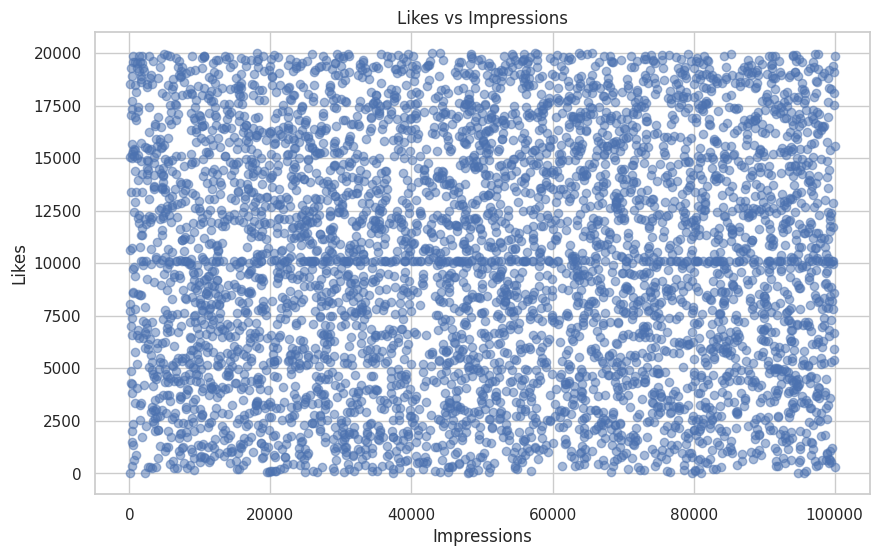

In [42]:
# Data Visualization
# Matplotlib Visualizations

# Scatter Plot: Likes vs Impressions

plt.figure(figsize=(10, 6))

plt.scatter(
    df['impression_count'],
    df['likes'],
    alpha=0.5
)

plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.title('Likes vs Impressions')

plt.show()

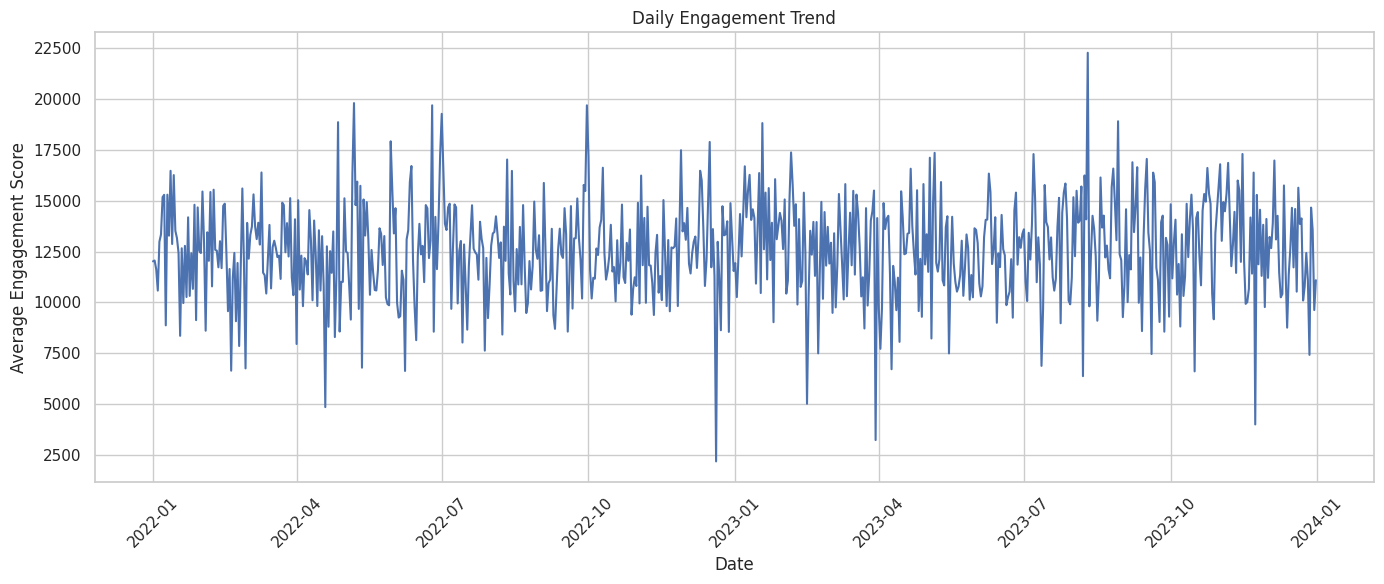

In [43]:
# Daily Engagement Trend

daily_engagement = (
    df.groupby('posted_at')['engagement_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_engagement['posted_at'],
    daily_engagement['engagement_score']
)

plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.title('Daily Engagement Trend')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

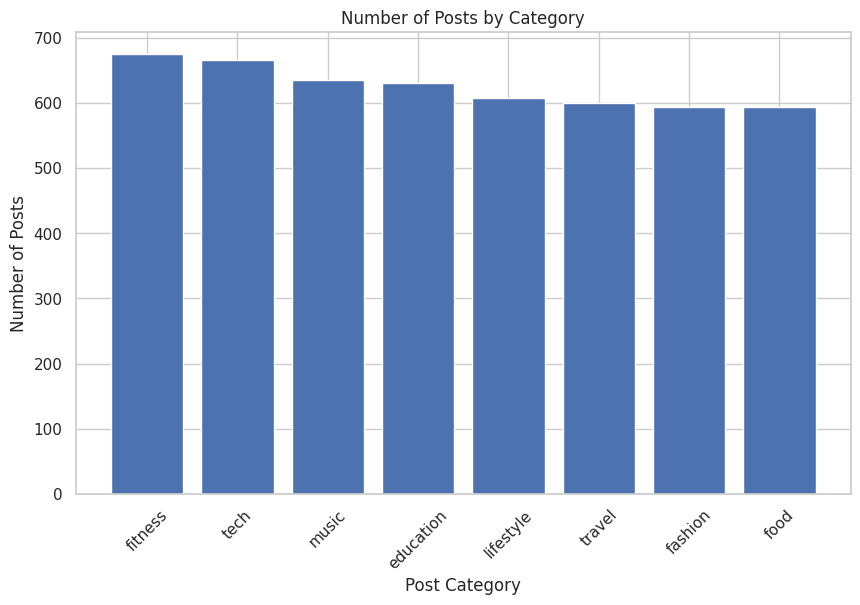

In [44]:
# Posts by Category
# Bar Chart

category_counts = df['post_category'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Number of Posts by Category')

plt.xticks(rotation=45)

plt.show()

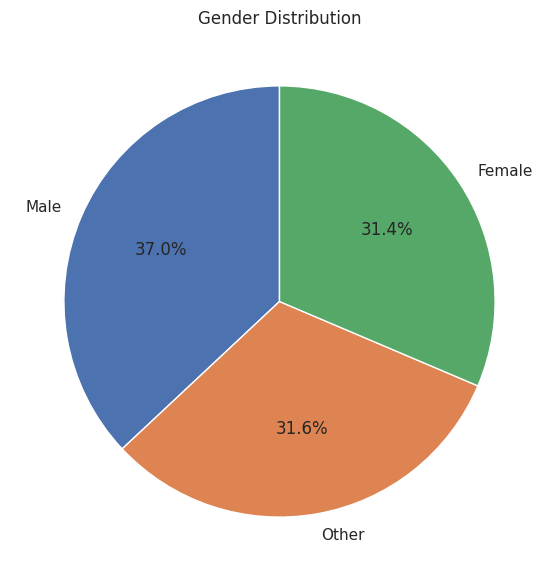

In [45]:
# Gender Distribution
# pie chart
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution')

plt.show()

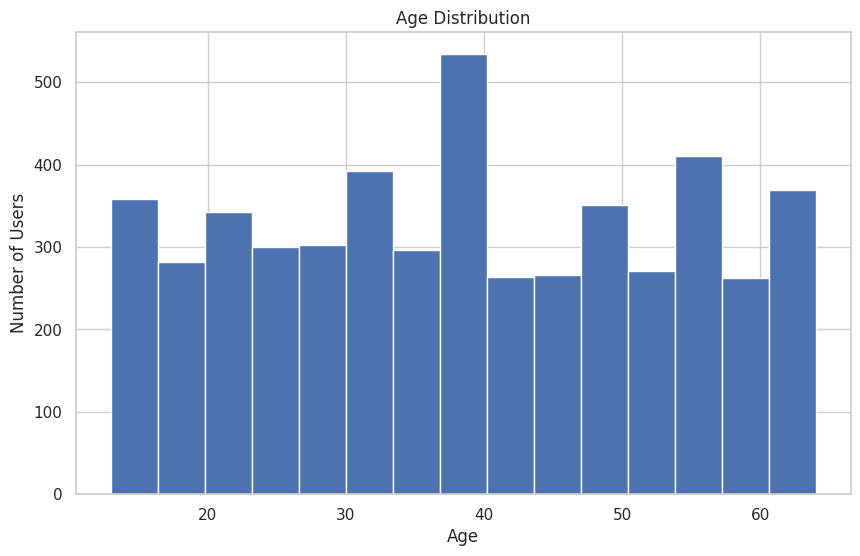

In [46]:
# Age Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    df['age'],
    bins=15
)

plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.title('Age Distribution')

plt.show()

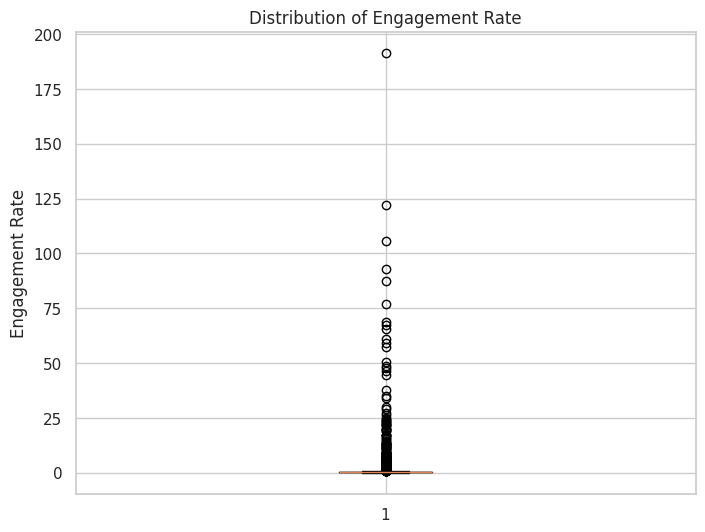

In [47]:
# Engagement Rate Box Plot

plt.figure(figsize=(8, 6))

plt.boxplot(
    df['calculated_engagement_rate'],
    vert=True
)

plt.ylabel('Engagement Rate')
plt.title('Distribution of Engagement Rate')

plt.show()

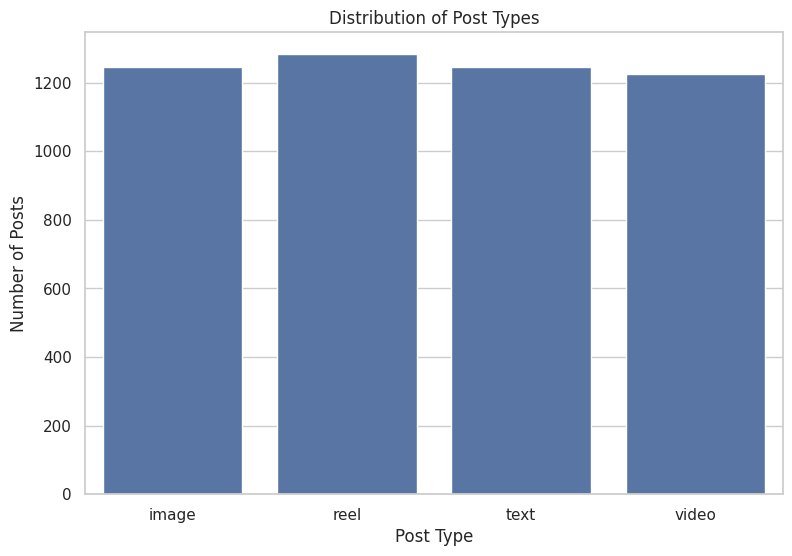

In [48]:
# Seaborn Visualizations
# Count Plot: Post Type

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='post_type'
)

plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Distribution of Post Types')

plt.show()

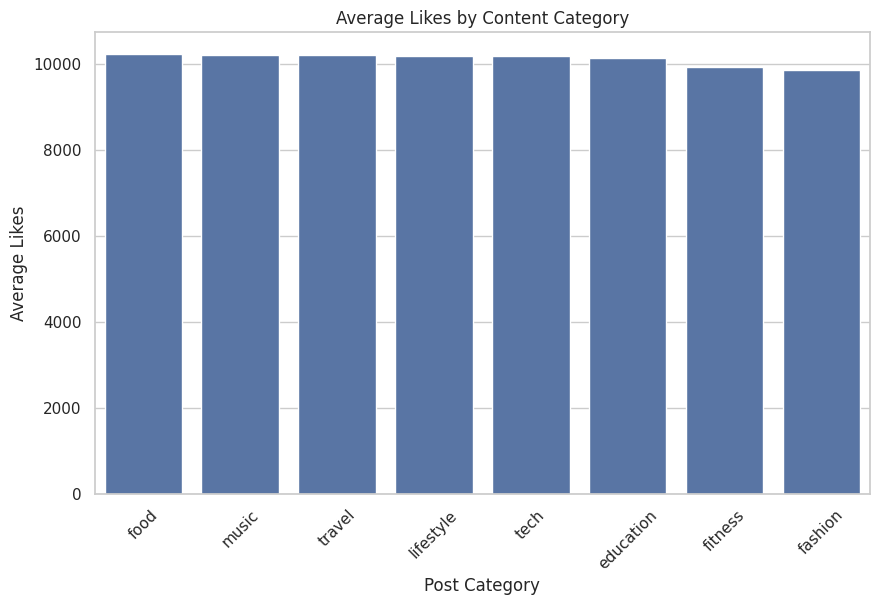

In [49]:
# Average Likes by Category

avg_likes_category = (
    df.groupby('post_category')['likes']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=avg_likes_category,
    x='post_category',
    y='likes'
)

plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Content Category')

plt.xticks(rotation=45)

plt.show()

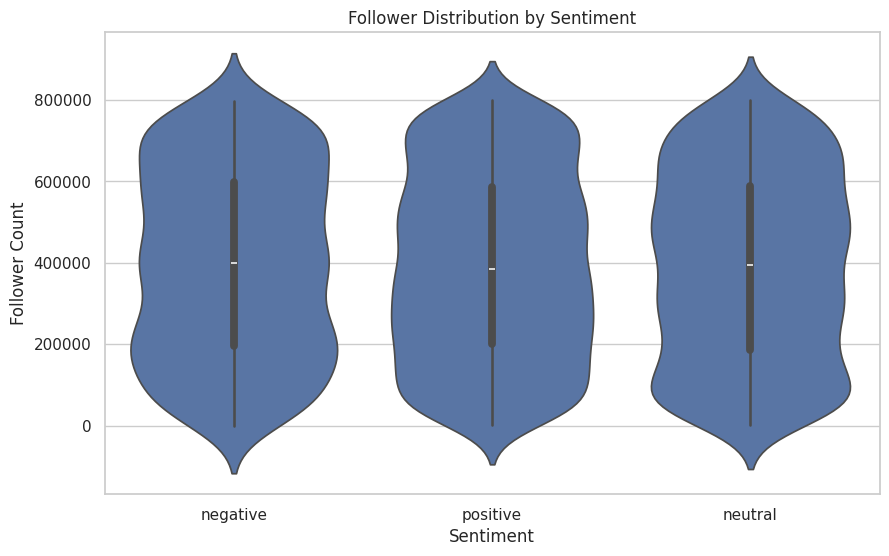

In [50]:
# Violin Plot: Followers vs Sentiment

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count'
)

plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Follower Distribution by Sentiment')

plt.show()

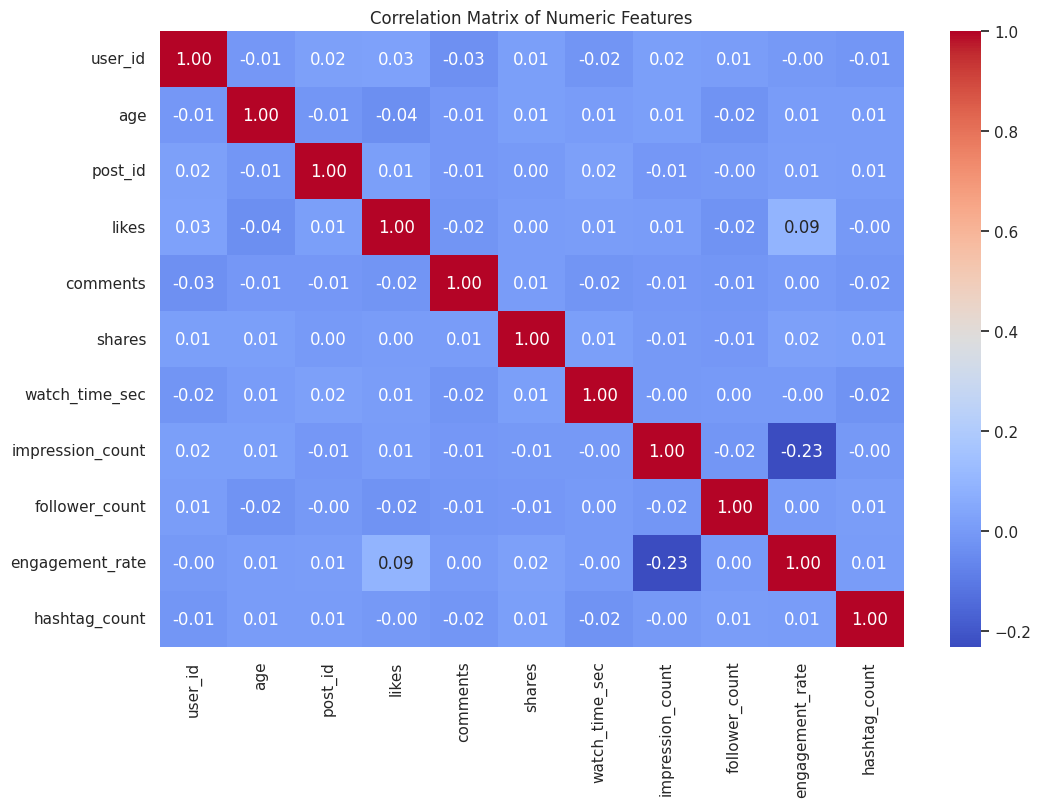

In [51]:
# Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numeric Features')

plt.show()

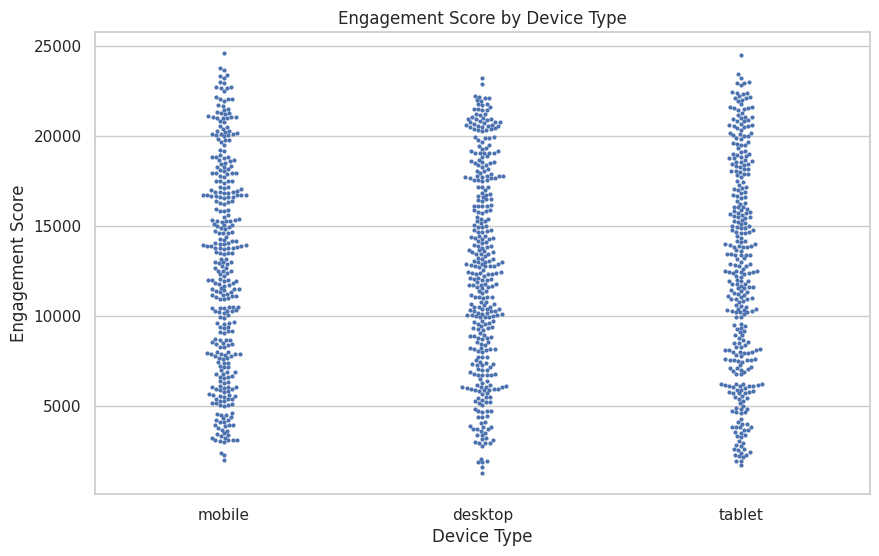

In [52]:
# Swarm Plot: Engagement vs Device

sample_df = df.sample(
    min(1000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=sample_df,
    x='device_type',
    y='engagement_score',
    size=3
)

plt.xlabel('Device Type')
plt.ylabel('Engagement Score')
plt.title('Engagement Score by Device Type')

plt.show()

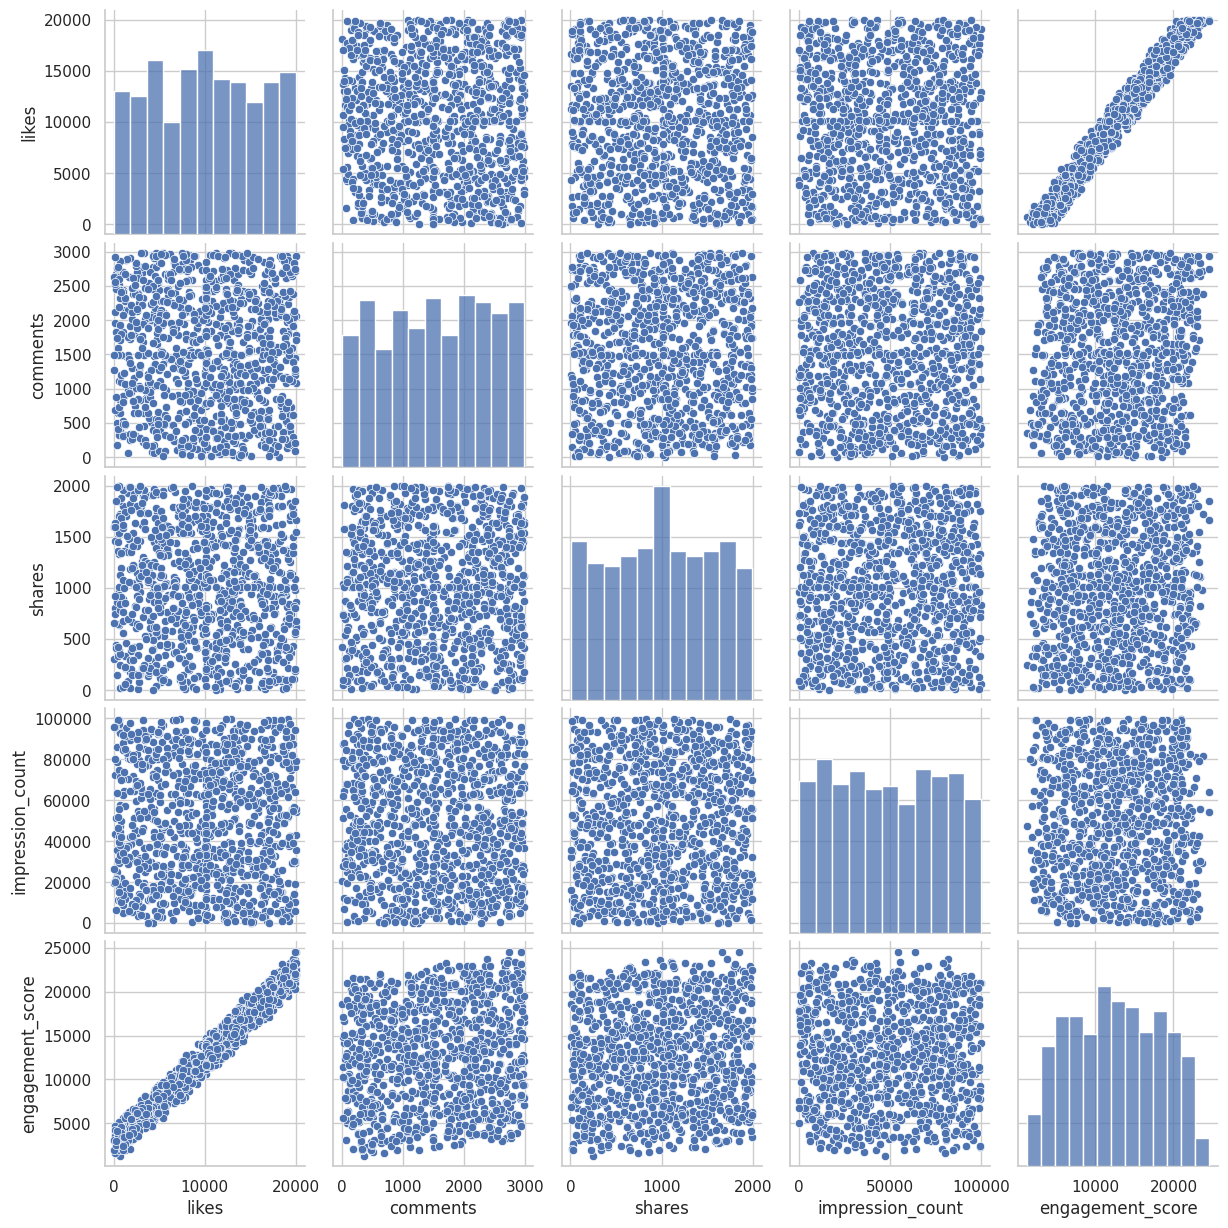

In [53]:
# Pair Plot

pair_columns = [
    'likes',
    'comments',
    'shares',
    'impression_count',
    'engagement_score'
]

sns.pairplot(
    df[pair_columns].sample(
        min(1000, len(df)),
        random_state=42
    )
)

plt.show()

In [54]:
# Plotly Interactive Visualization
# Interactive Engagement Trend

daily_plotly = (
    df.groupby('posted_at')
    .agg(
        engagement=('engagement_score', 'mean'),
        impressions=('impression_count', 'mean')
    )
    .reset_index()
)

fig = px.line(
    daily_plotly,
    x='posted_at',
    y='engagement',
    title='Interactive Daily Engagement Trend',
    markers=True
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Average Engagement Score'
)

fig.show()

In [55]:
# Interactive Bubble Chart

fig = px.scatter(
    df.sample(min(1500, len(df)), random_state=42),
    x='impression_count',
    y='engagement_score',
    size='likes',
    color='post_category',
    hover_data=[
        'country',
        'post_type',
        'sentiment',
        'device_type'
    ],
    title='Interactive Social Media Engagement Analysis'
)

fig.show()

In [56]:
# Final Insights
# Best Post Type

best_post_type = (
    df.groupby('post_type')['engagement_score']
    .mean()
    .sort_values(ascending=False)
)

print("Average Engagement by Post Type:")
print(best_post_type)

print(
    "\nHighest-performing Post Type:",
    best_post_type.idxmax()
)


Average Engagement by Post Type:
post_type
video    12664.594286
image    12649.390537
text     12613.243775
reel     12524.031567
Name: engagement_score, dtype: float64

Highest-performing Post Type: video


In [57]:
# Best Content Category

best_category = (
    df.groupby('post_category')['engagement_score']
    .mean()
    .sort_values(ascending=False)
)

print("Average Engagement by Category:")
print(best_category)

print(
    "\nBest-performing Content Category:",
    best_category.idxmax()
)

Average Engagement by Category:
post_category
music        12788.549606
food         12739.200675
tech         12686.490226
travel       12650.559167
lifestyle    12639.539539
education    12578.270206
fitness      12457.791852
fashion      12356.420875
Name: engagement_score, dtype: float64

Best-performing Content Category: music


In [58]:
# Countries with Highest Engagement Rate

best_countries = (
    df.groupby('country')['calculated_engagement_rate']
    .mean()
    .sort_values(ascending=False)
)

print("Average Engagement Rate by Country:")
print(best_countries)

print(
    "\nCountry with Highest Average Engagement Rate:",
    best_countries.idxmax()
)

Average Engagement Rate by Country:
country
Brazil       1.536914
Australia    1.325233
France       1.146314
Uae          1.107977
Canada       0.914443
Uk           0.851996
Japan        0.770065
Germany      0.756039
India        0.665109
Usa          0.572188
Name: calculated_engagement_rate, dtype: float64

Country with Highest Average Engagement Rate: Brazil


In [59]:
# Age and Engagement

age_engagement = (
    df.groupby('age')['engagement_score']
    .mean()
    .sort_values(ascending=False)
)

print("Top Ages by Average Engagement:")
print(age_engagement.head(10))

Top Ages by Average Engagement:
age
49.0    14162.194444
17.0    14156.450000
33.0    13796.268817
14.0    13469.014706
36.0    13468.524752
39.0    13462.858025
50.0    13418.241379
31.0    13279.258427
38.0    13245.217803
25.0    13195.344340
Name: engagement_score, dtype: float64


In [60]:
# Age Group Analysis

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 17, 25, 35, 45, 55, 100],
    labels=[
        'Under 18',
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56+'
    ]
)

age_group_analysis = (
    df.groupby('age_group', observed=True)
    .agg(
        posts=('post_id', 'count'),
        avg_engagement=('engagement_score', 'mean'),
        avg_likes=('likes', 'mean'),
        avg_watch_time=('watch_time_sec', 'mean')
    )
)

age_group_analysis

,posts,avg_engagement,avg_likes,avg_watch_time
age_group,,,,
Under 18,448,13104.754464,10616.745536,3955.506696
18-25,742,12608.139488,10139.995283,4070.376011
26-35,981,12768.703874,10240.393986,3970.523955
36-45,1076,12741.579461,10220.458643,4043.873606
46-55,919,12373.489663,9841.261153,4001.347116
56+,834,12261.744005,9793.344724,4024.820144


In [61]:
# Verified vs Non-Verified Accounts

verified_analysis = (
    df.groupby('is_verified')
    .agg(
        posts=('post_id', 'count'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comments', 'mean'),
        avg_shares=('shares', 'mean'),
        avg_engagement=('engagement_score', 'mean'),
        avg_engagement_rate=('calculated_engagement_rate', 'mean'),
        avg_impressions=('impression_count', 'mean')
    )
)

verified_analysis

,posts,avg_likes,avg_comments,avg_shares,avg_engagement,avg_engagement_rate,avg_impressions
is_verified,,,,,,,
False,4517,10137.201129,1505.511401,1001.599292,12644.311822,0.953398,49935.288244
True,483,9824.533126,1469.573499,1015.173913,12309.280538,1.061911,50747.343685


In [62]:
# Best Time of Day for Impressions

hour_analysis = (
    df.groupby('hour')['impression_count']
    .mean()
    .sort_values(ascending=False)
)

print("Average Impressions by Hour:")
print(hour_analysis)

print(
    "\nBest Hour for Impressions:",
    hour_analysis.idxmax()
)

Average Impressions by Hour:
hour
0    50013.7328
Name: impression_count, dtype: float64

Best Hour for Impressions: 0


In [63]:
# Device Type Impact on Watch Time

device_analysis = (
    df.groupby('device_type')
    .agg(
        avg_watch_time=('watch_time_sec', 'mean'),
        avg_engagement=('engagement_score', 'mean'),
        avg_impressions=('impression_count', 'mean')
    )
    .sort_values(
        'avg_watch_time',
        ascending=False
    )
)

device_analysis

,avg_watch_time,avg_engagement,avg_impressions
device_type,,,
mobile,4087.830760,12663.194477,49516.948931
tablet,3979.736429,12463.280458,49597.971049
desktop,3974.792521,12708.564837,50934.068758


In [64]:
# Sentiment Performance

sentiment_performance = (
    df.groupby('sentiment')
    .agg(
        posts=('post_id', 'count'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comments', 'mean'),
        avg_shares=('shares', 'mean'),
        avg_engagement=('engagement_score', 'mean'),
        avg_engagement_rate=('calculated_engagement_rate', 'mean')
    )
    .sort_values(
        'avg_engagement_rate',
        ascending=False
    )
)

sentiment_performance

,posts,avg_likes,avg_comments,avg_shares,avg_engagement,avg_engagement_rate
sentiment,,,,,,
negative,960,10208.096875,1516.094792,1007.307292,12731.498958,1.038299
neutral,1527,9923.194499,1528.404060,996.565160,12448.163720,0.990728
positive,2513,10180.062077,1480.650617,1005.086749,12665.799443,0.919138


In [65]:
# Negative vs Neutral Posts

negative_neutral = (
    df[df['sentiment'].isin(['negative', 'neutral'])]
    .groupby('sentiment')
    .agg(
        posts=('post_id', 'count'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comments', 'mean'),
        avg_shares=('shares', 'mean'),
        avg_watch_time=('watch_time_sec', 'mean'),
        avg_impressions=('impression_count', 'mean'),
        avg_engagement=('engagement_score', 'mean')
    )
)

negative_neutral

,posts,avg_likes,avg_comments,avg_shares,avg_watch_time,avg_impressions,avg_engagement
sentiment,,,,,,,
negative,960,10208.096875,1516.094792,1007.307292,4054.639583,50191.960417,12731.498958
neutral,1527,9923.194499,1528.404060,996.565160,4031.823183,49515.971185,12448.163720


In [66]:
# Automatically Generate Final Insights

best_post = (
    df.groupby('post_type')['engagement_score']
    .mean()
    .idxmax()
)

best_post_value = (
    df.groupby('post_type')['engagement_score']
    .mean()
    .max()
)

best_category = (
    df.groupby('post_category')['engagement_score']
    .mean()
    .idxmax()
)

best_category_value = (
    df.groupby('post_category')['engagement_score']
    .mean()
    .max()
)

best_country = (
    df.groupby('country')['calculated_engagement_rate']
    .mean()
    .idxmax()
)

best_country_rate = (
    df.groupby('country')['calculated_engagement_rate']
    .mean()
    .max()
)

best_device = (
    df.groupby('device_type')['watch_time_sec']
    .mean()
    .idxmax()
)

best_device_watch = (
    df.groupby('device_type')['watch_time_sec']
    .mean()
    .max()
)

best_sentiment = (
    df.groupby('sentiment')['calculated_engagement_rate']
    .mean()
    .idxmax()
)

best_hour = (
    df.groupby('hour')['impression_count']
    .mean()
    .idxmax()
)

print("=" * 60)
print("FINAL BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"\n1. Best Post Type: {best_post}"
    f" with average engagement score of {best_post_value:.2f}"
)

print(
    f"\n2. Best Content Category: {best_category}"
    f" with average engagement score of {best_category_value:.2f}"
)

print(
    f"\n3. Highest Engagement Rate Country: {best_country}"
    f" with average rate of {best_country_rate:.4f}"
)

print(
    f"\n4. Device with Highest Watch Time: {best_device}"
    f" with average watch time of {best_device_watch:.2f} seconds"
)

print(
    f"\n5. Best Performing Sentiment: {best_sentiment}"
)

print(
    f"\n6. Best Hour for Impressions: {best_hour}:00"
)

FINAL BUSINESS INSIGHTS

1. Best Post Type: video with average engagement score of 12664.59

2. Best Content Category: music with average engagement score of 12788.55

3. Highest Engagement Rate Country: Brazil with average rate of 1.5369

4. Device with Highest Watch Time: mobile with average watch time of 4087.83 seconds

5. Best Performing Sentiment: negative

6. Best Hour for Impressions: 0:00


In [67]:
print("FINAL DATASET INFORMATION")
print("=" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFinal Columns:")
print(df.columns.tolist())

FINAL DATASET INFORMATION
Rows: 5000
Columns: 32

Missing Values:
0

Duplicate Rows:
0

Final Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score', 'calculated_engagement_rate', 'year', 'month', 'month_name', 'day', 'day_name', 'hour', 'log_followers', 'log_impressions', 'log_likes', 'age_group']
